In [92]:
#before training our models for prediction, we need an ideal dataset from prolly an already existing raw dataset wherein we can  modify that dataset using python libraries like panda(used for reading a dataset), numpy (used for working with arrays , 1d n 2d) , seaborn and matplot lib (for datavisualisation) . this process is called exploratory data analysis .

In [93]:
#importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline



In [94]:
#importing and reading data
train = pd.read_csv('data/titanic_train.csv')

In [95]:
#reading the data
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


EXPLORATORY DATA ANALYSIS

In [96]:
#1. Missing data .
#we check for nan values or null / missing values ino ur dataset
train.isnull()
#true means it is null.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

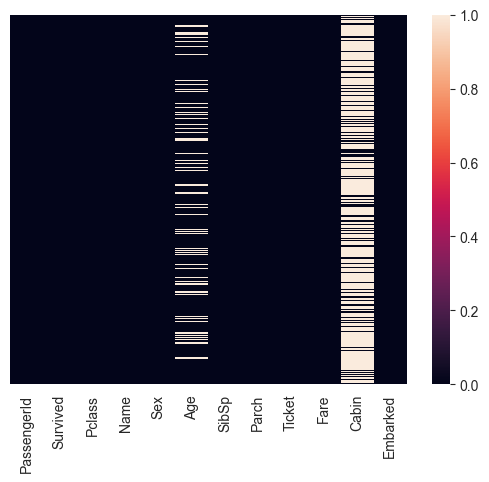

In [97]:
#the data above doesnt show the values for entire dataset all at once ,# so we create a heatmap to look for null values.
sns.heatmap(train.isnull(), yticklabels = False )
#yticklabels ensures the y axis doesnt have any values .
#dark bar sshow the null values

<Axes: xlabel='Survived', ylabel='count'>

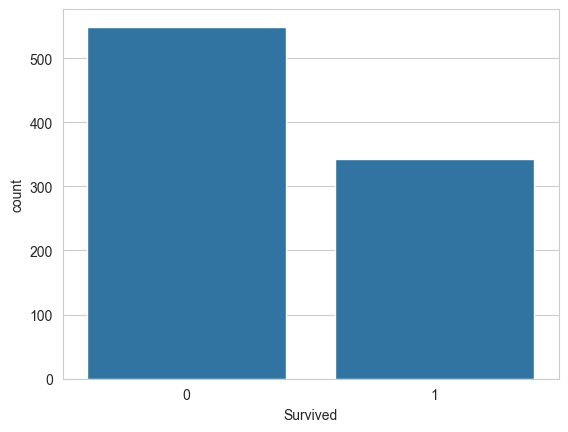

In [98]:
#using other visual representations
sns.set_style('whitegrid')
sns.countplot(x = 'Survived', data = train)

<Axes: xlabel='Survived', ylabel='count'>

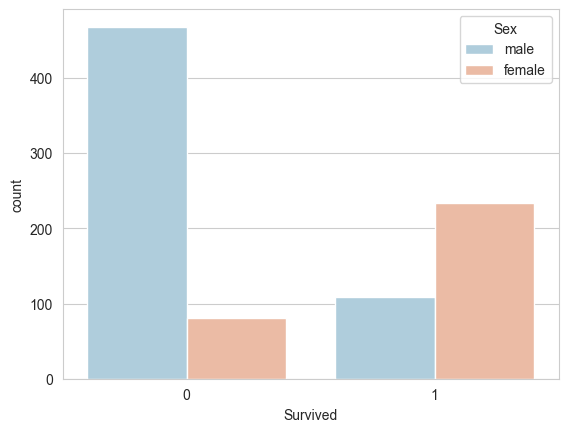

In [99]:
sns.set_style('whitegrid')
sns.countplot(x = 'Survived', hue = 'Sex', data = train, palette = 'RdBu_r')

<Axes: xlabel='Survived', ylabel='count'>

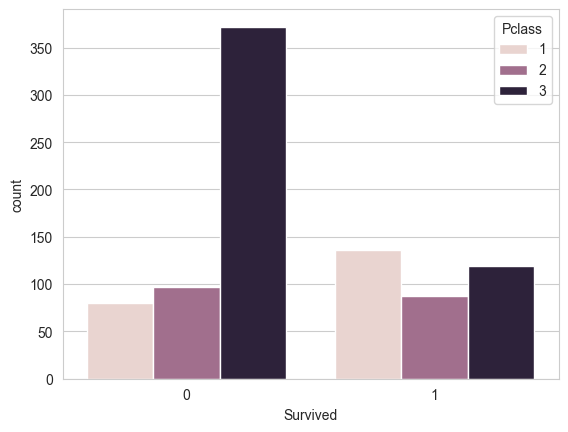

In [100]:
#hue helps is categorising diff categories
sns.set_style('whitegrid')
sns.countplot(x = 'Survived' , hue = 'Pclass',  data = train)

/var/folders/b6/dbbdf8r51l51p_fc8dv0br_m0000gn/T/ipykernel_8361/3338295546.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'].dropna(), kde = False , color = 'darked ', bins = 40)


ValueError: 'darked ' is not a valid color value.

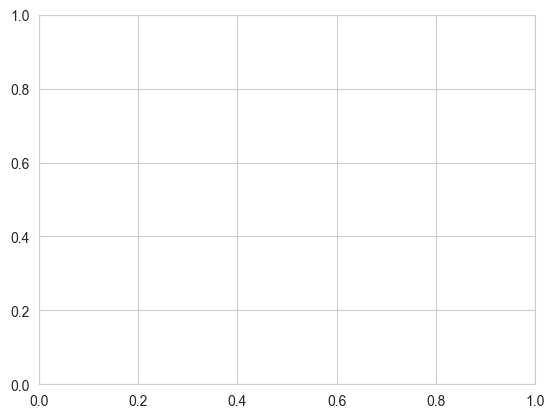

In [101]:
sns.distplot(train['Age'].dropna(), kde = False , color = 'darked ', bins = 40)

<Axes: xlabel='SibSp', ylabel='count'>

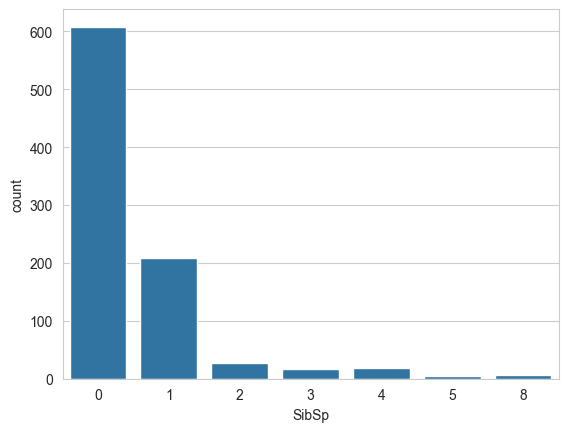

In [25]:
sns.countplot(x = 'SibSp' , data = train )


DATA CLEANING


<Axes: xlabel='Pclass', ylabel='Age'>

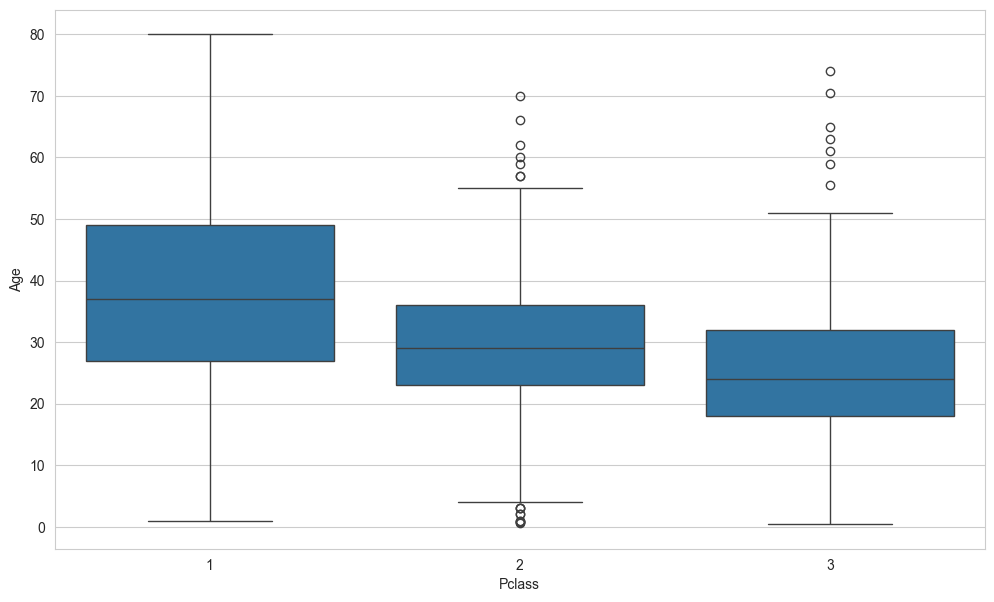

In [27]:
#our goal is to now remove the nan value columns , but before that , we plot a box plot which can help us to determine the avg value across categories
plt.figure(figsize= (12, 7 ))
sns.boxplot(x = 'Pclass' , y ='Age' , data = train )

#avg age for 1class = 35, 2 class = 27 , 3 class = 24 )


In [ ]:
 #imputation in Python refers to the process of replacing missing values (NaNs) in a dataset with estimated or predicted values. This is a critical step in data preprocessing because most machine learning models cannot handle incomplete data.

In [81]:
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age): #if age is misisng , use pclas to fill age

        if Pclass == 1: #if pclass is 1  put age as 35 instead of null
            return 35
        elif Pclass == 2:
            return 27
        else:
            return 24
    else:
        return Age

In [78]:
#now applying the function .
train['Age']  = train[['Age', 'Pclass']].apply(impute_age )
#For each row:
#Pass Age and Pclass into function
#Replace Age with:
#Original value (if present)
#Estimated value (if missing)

<Axes: >

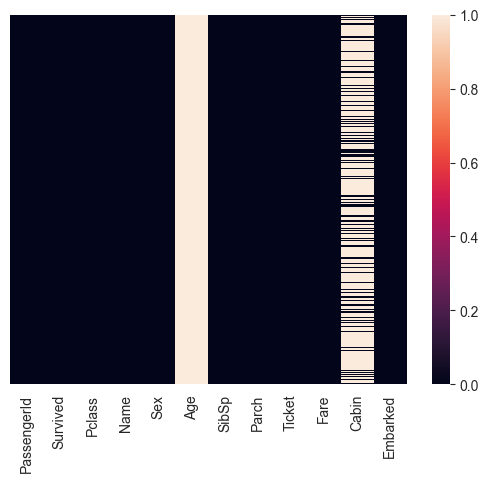

In [79]:
#checking the heat map again
sns.heatmap(train.isnull(), yticklabels = False )

In [ ]:
#to replace the cabin null values with other values , we need ot earn feature engineering (in next tutorial). For now , we just drop the entire column.

In [62]:
train.drop('Cabin' , axis = 1 , inplace = True )

In [64]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,NaN,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,NaN,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,NaN,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,NaN,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,NaN,0,0,373450,8.0500,S


In [ ]:
#fromabove , my age vlaues are still not updated

In [ ]:
#we need to convert categorical features into dummy variables using pandas . Otherwise our ml algo wont be able to directly take in those features as inputs

In [102]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [106]:
pd.get_dummies(train['Embarked'], drop_first = True).head()


,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [ ]:
#working on the second categorical features and removing the first column, since one enough todetermine the sex.

In [108]:
sex = pd.get_dummies(train['Sex'], drop_first = True)
embark = pd.get_dummies(train['Embarked'] , drop_first = True )

In [110]:
train.drop(['Sex', 'Embarked', 'Name', 'Ticket'] , axis = 1 , inplace = True  )


In [111]:
train.drop('Cabin' , axis =1 , inplace = True )


In [112]:
train.head()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [113]:
train.dropna(inplace = True )


In [118]:
#importing logistic regression model
from sklearn.model_selection import train_test_split

In [119]:
X_train , X_test , y_train, y_test = train_test_split(train.drop('Survived' , axis = 1),train['Survived'], test_size = 0.30, random_state = 101)

TRAINING AND PREDICTING DATA


In [120]:
from sklearn.linear_model import LogisticRegression
#importing the logistic cregression model


In [121]:
logmodel = LogisticRegression()
logmodel.fit(X_train , y_train)

/Users/smritimishra/PycharmProjects/JupyterProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
#import problems faced